# **FICO® Xpress MoselPy - Chapter A: Blending and process planning**

***mining_process.ipynb*** - Mining and process industries: blending, refinery, sugar harvest processing, mining and electricity dispatch examples using MoselPy.

&copy; Copyright 2026 Fair Isaac Corporation. The use of this example is subject to [legal and license requirements](https://github.com/fico-xpress/xpress-community#legal-and-license-requirements).

In [ ]:
# Install the necessary packages
%pip install -q moselpy mosellibs xpresslibs matplotlib pandas

Run the cell below to import the necessary libraries and set `MODELS` and `DATA`, the path variables pointing to the Mosel model files and data files used in this notebook.

In [ ]:
# On Linux, preload the Xpress solver library so the Mosel optimizer module
# (mmxprs) can resolve it at runtime.
import sys, os, glob, ctypes, xpresslibs
if sys.platform == "linux":
    for _lib in glob.glob(os.path.join(xpresslibs.solver_libs_dir, "libxprs.so*")):
        ctypes.CDLL(_lib, mode=ctypes.RTLD_GLOBAL)

import moselpy as mp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

MODELS = "models/mining_process"
DATA   = "data/mining_process"

print(f"MoselPy {mp.version}  |  Mosel {mp.mosel_version}  |  Xpress {mp.xpress_version}")
mp.config.set_default_stream(mp.StreamType.OUTPUT, "null:")

MoselPy 6.12.0  |  Mosel 6012000  |  Xpress 10000000


## Mining and process industries

This notebook covers six LP and MIP examples from Chapter A of the Xpress Applications Book, solved via [MoselPy](https://pypi.org/project/moselpy/). All models share a common theme: relating to typical problems in the process and mining industry - determining how to **blend raw materials**, **plan production processes**, or **schedule harvest processing** to meet requirements at minimum cost.

> **Mosel source files:** [`models/mining_process/`](models/mining_process/) &nbsp;|&nbsp; **Data files:** [`data/mining_process/`](data/mining_process/)

> **Requirements:** `pip install moselpy mosellibs xpresslibs` - `mosellibs` provides the Mosel runtime and `xpresslibs` the Xpress solver libraries. No local Xpress installation is needed to run these notebooks, as long as the packages with libraries have been installed.

> A local FICO&reg; Xpress installation is recommended if you want access to the full set of examples, user guides and documentation, solver libraries, and Xpress Workbench. Obtain one via the [FICO&reg; Xpress community license](https://www.fico.com/en/fico-xpress-community-license) page. If a local installation is present, set `XPRESSDIR` before starting Jupyter to use it instead of the `mosellibs` and `xpresslibs` packages.

> **MoselPy documentation:** [MoselPy User Guide and Reference Manual](https://www.fico.com/fico-xpress-optimization/docs/latest/mosel/MoselPy/dhtml)

> **Mosel examples on the web:** [examples.xpress.fico.com](https://examples.xpress.fico.com/example.pl?id=mosel_app_1)

### MoselPy features demonstrated in this chapter

- **Compile-load-run sequence**: A-1, A-5, and A-6 compile the model to a `.bim` file and call `load_model()` to enable multiple runs or introspection.
- **Single execution command**: A-2, A-3, and A-4 use `mp.execute_model()` for one-off runs with no `.bim` written to disk.
- **`find_identifier(use_pandas=True)` + `unstack()`**: A-2 retrieves the 2D blending solution as a MultiIndex Series and pivots it into a readable DataFrame.
- **Sensitivity analysis**: A-6 runs a parametric loop varying demand and collects total costs into a `pd.DataFrame`.

### Workflow patterns

This notebook uses different MoselPy patterns depending on the use case:

- The Mosel source files in [`models/mining_process/`](models/mining_process/) have been adapted to receive data from Python via `input_data`, while remaining runnable as standalone Mosel models using their `.dat` files.
- **One-step compile and run** (`execute_model`): compiles and runs the model in a single call, returning `(model, output_dict)`. Used for models that run once and need no `.bim` on disk.
- **Three-step** (`compile_model` → `load_model` → `run`): when the same compiled model is used multiple times (e.g. running multiple scenarios) or when model introspection is useful.
- **Context manager** (`with mp.load_model(...) as model:`): ensures Mosel resources are freed as soon as the block exits, without needing an explicit close.

Input data is passed from Python via `input_data`; the standalone `.dat` files remain available for running models outside Python. Results come back via `model.run()`'s return dict (for items in `initializations to OUTFILE`) or via `model.find_identifier()` for any `public`-declared entity.

## A-1 Production of alloys (LP)

*Applications Book Chapter A, Example 1*

> **Mosel model:** [`a1alloy_p.mos`](models/mining_process/a1alloy_p.mos)

A steelworks must produce 500 tonnes of steel satisfying carbon (C), copper (Cu), and manganese (Mn) grade requirements. Seven raw materials (iron and copper alloys, aluminium) are available at different costs and in limited quantities. The objective is to minimize total raw material cost.

**Sets:** $\text{RAW} = 1..7$ (raw materials), $\text{COMP} = 1..3$ (chemical elements: C, Cu, Mn)

**Decision variables:** $\text{use}_r \geq 0$ (tonnes of raw material $r$ used); $\text{produce} \geq 0$ (total steel produced).

$$
\begin{align*}
\text{minimize}   \quad & \sum_{r} \text{COST}_r \cdot \text{use}_r \\
\text{subject to} \quad & \text{produce} = \sum_r \text{use}_r \\
                          & \text{PMIN}_c \cdot \text{produce} \leq \sum_r P_{r,c} \cdot \text{use}_r \leq \text{PMAX}_c \cdot \text{produce} \quad \forall\, c \\
                          & \text{use}_r \leq \text{AVAIL}_r \quad \forall\, r \\
                          & \text{produce} \geq \text{DEM}
\end{align*}
$$

Define the seven raw materials with their chemical compositions ($P$ matrix), costs, and availabilities.

For 2-D Mosel arrays, MoselPy requires a dict with `(row, col)` tuple keys. A 1-D list maps element-by-element to the declared index set (1-indexed).

The heatmap below shows the percentage of each chemical element (Carbon, Copper, Manganese) in each raw material. Most materials are specialists: iron alloys carry carbon and manganese; copper alloys are almost pure copper.

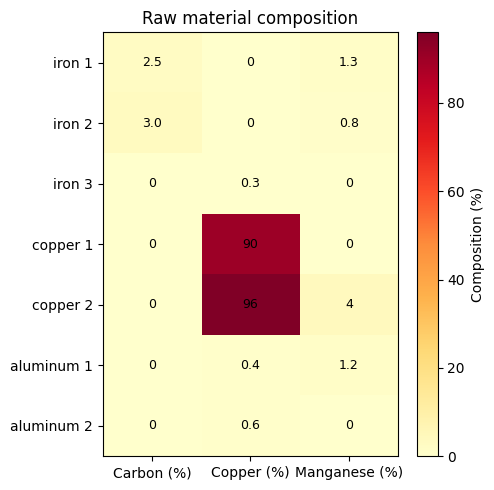

In [ ]:
NR, NC = 7, 3
P_data = [[2.5, 0, 1.3], [3.0, 0, 0.8], [0, 0.3, 0],
          [0, 90, 0], [0, 96, 4], [0, 0.4, 1.2], [0, 0.6, 0]]  # composition (% C, Cu, Mn) per raw material
P     = {(r+1, c+1): P_data[r][c] for r in range(NR) for c in range(NC)}  # dict with (raw, comp) tuple keys
PMIN  = [2.0, 0.4, 1.2]                                                    # min grade requirement per element (%)
PMAX  = [3.0, 0.6, 1.65]                                                   # max grade requirement per element (%)
AVAIL = [400, 300, 600, 500, 200, 300, 250]                                # availability (tonnes) per raw material
COST  = [200, 250, 150, 220, 240, 200, 165]                                # cost ($/tonne) per raw material
NAMES = ["iron 1", "iron 2", "iron 3", "copper 1", "copper 2",
         "aluminum 1", "aluminum 2"]                                       # raw material names
DEM   = 500                                                                # steel demand (tonnes)

fig, ax = plt.subplots(figsize=(5, 5))
comp_data = P_data
im = ax.imshow(comp_data, cmap="YlOrRd", aspect="auto")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Carbon (%)", "Copper (%)", "Manganese (%)"])
ax.set_yticks(range(NR)); ax.set_yticklabels(NAMES)
for r in range(NR):
    for c in range(NC):
        ax.text(c, r, f"{comp_data[r][c]}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Composition (%)")
ax.set_title("Raw material composition")
plt.tight_layout(); plt.show()

The code cell below uses `compile_model`, `load_model`, and `run` to compile and solve the alloy blending LP.

`exec_params` overrides the model's `DATASOURCE` and `OUTFILE` parameters to `"moselpy:"`, redirecting data I/O through Python instead of files. `input_data` passes the `NR` × `NC` composition matrix `P` (as a dict with `(row, col)` tuple keys), grade bounds, availabilities, costs, and demand defined above. After `load_model()`, `model.name` and `model.size` are available for introspection before any `run()` call. After the run, `model.find_identifier()` retrieves any `public`-declared model entity by name - scalars come back as `float`, arrays as dicts keyed by index.

In [ ]:
mp.compile_model(f"{MODELS}/a1alloy_p.mos", f"{MODELS}/a1alloy_p.bim")
model = mp.load_model(f"{MODELS}/a1alloy_p.bim")
print(f"Model: '{model.name}'  |  compiled size: {model.size:,} bytes")
output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"NR": NR, "NC": NC, "P": P, "PMIN": PMIN, "PMAX": PMAX, "AVAIL": AVAIL,
                "COST": COST, "DEM": DEM, "NAMES": NAMES},
)

obj_val     = output["obj_val"]
sol_produce = output["sol_produce"]
sol_use     = output["sol_use"]

print(f"Total cost:    ${obj_val:,.2f}")
print(f"Steel produced: {sol_produce:.0f} tonnes")
print()
print(f"{'Raw material':<14} {'Used (t)':>10}")
for r in range(1, 8):
    v = sol_use[r]
    if v > 0.01:
        print(f"  {NAMES[r-1]:<12} {v:>10.2f}")

Model: 'A-1 Production of Alloys'  |  compiled size: 9,672 bytes
Total cost:    $98,121.64
Steel produced: 500 tonnes

Raw material     Used (t)
  iron 1           400.00
  iron 3            39.78
  copper 2           2.76
  aluminum 1        57.46


The pie chart shows which raw materials contribute to the optimal blend and in what proportion, filtered to materials used above 0.01 t.

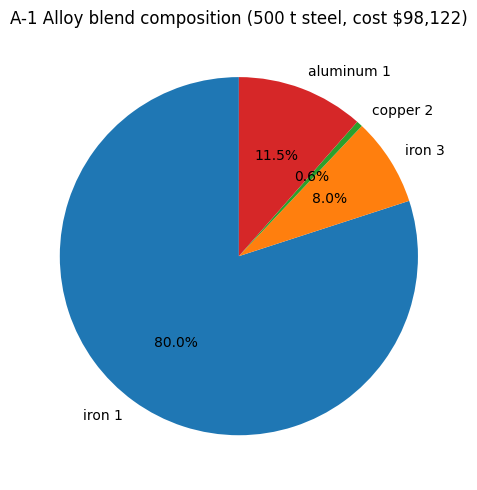

In [ ]:
blend = {NAMES[r-1]: sol_use[r] for r in range(1, 8) if sol_use[r] > 0.01}

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(list(blend.values()), labels=list(blend.keys()), autopct="%1.1f%%", startangle=90)
ax.set_title(f"A-1 Alloy blend composition ({sol_produce:.0f} t steel, cost ${obj_val:,.0f})")
plt.tight_layout(); plt.show()

## A-2 Animal food production (LP)

*Applications Book Chapter A, Example 2*

> **Mosel model:** [`a2food_p.mos`](models/mining_process/a2food_p.mos)

A farm produces two types of animal food by blending oat, maize, and molasses. Each food type must meet minimum protein and lipid requirements and a maximum fibre content. Raw material availabilities are limited. Four processing operations each add a cost per unit processed: grinding (oat and maize only), blending (all raw materials), granulating (food type 1), and sieving (food type 2). Minimize total production cost.

**Sets:** $\text{RAW} = \{\text{oat, maize, molasses}\}$, $\text{FOOD} = 1..2$, $\text{COMP} = 1..3$ (protein, lipid, fibre)

**Decision variables:** $\text{use}_{r,f} \geq 0$ (raw material $r$ used for food type $f$); $\text{produce}_f \geq 0$ (quantity of food $f$ produced).

$$
\begin{align*}
\text{minimize}   \quad & \sum_{r,\, f} \text{COST}_r \cdot \text{use}_{r,f}
                            + \text{PCOST}_{\text{grd}} \sum_{r \neq \text{mol},\, f} \text{use}_{r,f} \\
                          & + \text{PCOST}_{\text{bld}} \sum_{r,f} \text{use}_{r,f}
                            + \text{PCOST}_{\text{gra}} \sum_r \text{use}_{r,1}
                            + \text{PCOST}_{\text{siv}} \sum_r \text{use}_{r,2} \\
\text{subject to} \quad & \sum_r \text{use}_{r,f} = \text{produce}_f \quad \forall\, f \\
                          & \sum_r P_{r,c} \cdot \text{use}_{r,f} \geq \text{REQ}_c \cdot \text{produce}_f \quad \forall\, f,\, c \in \{1,2\} \quad \text{(min protein, lipid)} \\
                          & \sum_r P_{r,3} \cdot \text{use}_{r,f} \leq \text{REQ}_3 \cdot \text{produce}_f \quad \forall\, f \quad \text{(max fibre)} \\
                          & \sum_f \text{use}_{r,f} \leq \text{AVAIL}_r \quad \forall\, r \\
                          & \text{produce}_f \geq \text{DEM}_f \quad \forall\, f
\end{align*}
$$

Define the raw material data as a `pd.DataFrame` — one row per raw material, one column for availability and one for cost. The individual columns are passed as `pd.Series` to `input_data`, which MoselPy maps automatically to Mosel string-indexed arrays. Nutritional compositions, requirements, and demands are passed as plain dicts.

          availability  cost
oat              11900  0.13
maize            23500  0.17
molasses           750  0.12


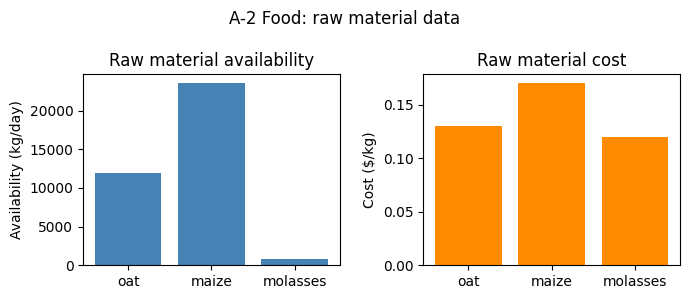

In [ ]:
NF, NC = 2, 3
raw_materials = ["oat", "maize", "molasses"]

# Raw material data as a DataFrame - columns become pd.Series inputs to the model
raw_df = pd.DataFrame({
    "availability": {"oat": 11900, "maize": 23500, "molasses":   750},
    "cost":         {"oat":  0.13, "maize":  0.17, "molasses":  0.12},
}, index=raw_materials)
print(raw_df.to_string())

P_rows = {"oat": [13.6, 7.1, 7.0], "maize": [4.1, 2.4, 3.7], "molasses": [5.0, 0.3, 25.0]}
P     = {(r, c+1): P_rows[r][c] for r in raw_materials for c in range(3)}
REQ   = {1: 9.5, 2: 2.0, 3: 6.0}
PCOST = {"grinding": 0.25, "blending": 0.05, "granulating": 0.42, "sieving": 0.17}
DEM   = {1: 9000, 2: 12000}

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].bar(raw_materials, raw_df["availability"], color="steelblue")
axes[0].set_ylabel("Availability (kg/day)"); axes[0].set_title("Raw material availability")
axes[1].bar(raw_materials, raw_df["cost"], color="darkorange")
axes[1].set_ylabel("Cost ($/kg)"); axes[1].set_title("Raw material cost")
plt.suptitle("A-2 Food: raw material data"); plt.tight_layout(); plt.show()

`mp.execute_model()` compiles and runs the model in one step, returning `(model, output_dict)`. `exec_params` overrides both `DATASOURCE` and `OUTFILE` to `"moselpy:"`, routing all data I/O through Python instead of files. `input_data` delivers the Python-side data at runtime. The returned `model` object remains usable after the run; the pandas cell below calls `model.find_identifier("sol_use", use_pandas=True)` to retrieve the result array directly as a pandas object.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/a2food_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"NF": NF, "NC": NC, "P": P, "REQ": REQ,
                "AVAIL": raw_df["availability"], "COST": raw_df["cost"],
                "PCOST": PCOST, "DEM": DEM},
)

obj_val     = output["obj_val"]
sol_use     = model.find_identifier("sol_use")    # dict with (raw, food) tuple keys
sol_produce = model.find_identifier("sol_produce")

print(f"Total cost: ${obj_val:,.2f}")
print()
print(f"{'Food type':<12}", end="")
for r in raw_materials:
    print(f"{r:>10}", end="")
print()
for f in [1, 2]:
    print(f"  type {f}     ", end="")
    for r in raw_materials:
        print(f"{sol_use[(r, f)]:>10.2f}", end="")
    print()

Total cost: $15,086.80

Food type          oat     maize  molasses
  type 1        5098.56   3719.53    181.91
  type 2        6798.07   4959.37    242.55


The stacked bar chart shows how each raw material is distributed across the two food types in the optimal blend.

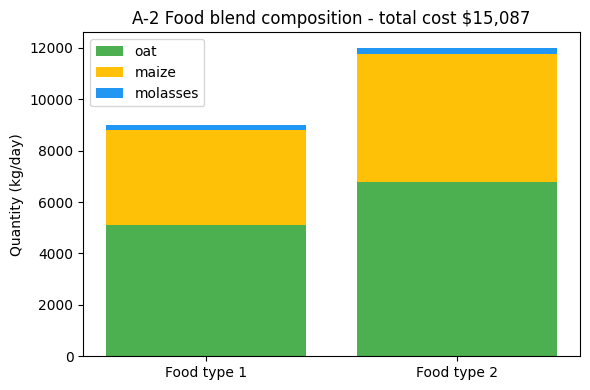

In [ ]:
raw_materials = ["oat", "maize", "molasses"]
food_labels = ["Food type 1", "Food type 2"]
data = np.array([[sol_use[(r, f)] for r in raw_materials] for f in [1, 2]])

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
bottom = np.zeros(2)
colors = ["#4CAF50", "#FFC107", "#2196F3"]
for i, (r, c) in enumerate(zip(raw_materials, colors)):
    ax.bar(x, data[:, i], bottom=bottom, label=r, color=c)
    bottom += data[:, i]
ax.set_xticks(x); ax.set_xticklabels(food_labels)
ax.set_ylabel("Quantity (kg/day)")
ax.set_title(f"A-2 Food blend composition - total cost ${obj_val:,.0f}")
ax.legend(); plt.tight_layout(); plt.show()

### Pandas output via `find_identifier`

`find_identifier("name", use_pandas=True)` returns array results as `pandas` objects: 1D arrays come back as `pd.Series` and 2D arrays as a `MultiIndex Series`. Call `.unstack()` to pivot one index level into columns and produce a `DataFrame` directly from a 2D result.

In [ ]:
# find_identifier with use_pandas=True returns a MultiIndex Series for 2D arrays.
# unstack pivots one index level to columns - here level 0 (raw material) becomes column headers.
sol_use_df = model.find_identifier("sol_use", use_pandas=True).unstack(level=0)
sol_use_df.index = [f"Food type {f}" for f in sol_use_df.index]
print(f"Raw material usage (kg/day)  - total cost ${obj_val:,.2f}")
print(sol_use_df.round(2).to_string())

Raw material usage (kg/day)  - total cost $15,086.80
               maize  molasses      oat
Food type 1  3719.53    181.91  5098.56
Food type 2  4959.37    242.55  6798.07


## A-3 Refinery planning (LP)

*Applications Book Chapter A, Example 3*

> **Mosel model:** [`a3refine_p.mos`](models/mining_process/a3refine_p.mos)

A refinery processes two crude oils through four operations (distillation, reforming, cracking, desulfurization) to produce butane, petrol, diesel, and heating oil. Monthly demands must be met, and petrol must satisfy octane, vapour pressure, and volatility specifications; diesel must meet a sulphur limit. Minimize total crude and processing cost.

**Sets:** $\text{CRUDES}$ (crude types); $\text{IDIST}$, $\text{IREF}$, $\text{ICRACK}$ (distillation, reforming, cracking streams); $\text{IPETROL}$, $\text{IDIESEL}$, $\text{IHO}$ (blend component streams); $\text{FINAL} = \{\text{butane, petrol, diesel, heating}\}$.

**Decision variables:** $\text{use}_c \geq 0$ (barrels of crude $c$ processed per month); $\text{produce}_p \geq 0$ (barrels of product $p$).

$$
\begin{align*}
\text{minimize}   \quad & \sum_{c \in \text{CRUDES}} \text{COST}_c \cdot \text{use}_c + \sum_{p \in \text{IDIST}} \text{COST}_p \cdot \text{produce}_p \\
\text{subject to} \quad & \text{produce}_p \leq \sum_c \text{DIST}_{c,p} \cdot \text{use}_c \quad \forall\, p \in \text{IDIST} \quad \text{(distillation yields)} \\
                          & \text{produce}_p \leq \text{REF}_p \cdot \text{produce}_{\text{naphtha}} \quad \forall\, p \in \text{IREF} \quad \text{(reforming)} \\
                          & \text{produce}_p \leq \text{CRACK}_p \cdot \text{produce}_{\text{residue}} \quad \forall\, p \in \text{ICRACK} \quad \text{(cracking)} \\
                          & \text{produce}_p = \sum_{s \in \text{streams}(p)} \text{produce}_s \quad \forall\, p \in \text{FINAL} \quad \text{(product assembly)} \\
                          & \sum_{p \in \text{IPETROL}} \text{OCT}_p \cdot \text{produce}_p \geq 94 \cdot \text{produce}_{\text{petrol}} \quad \text{(octane spec)} \\
                          & \sum_{p \in \text{IPETROL}} \text{VAP}_p \cdot \text{produce}_p \leq 12.7 \cdot \text{produce}_{\text{petrol}} \quad \text{(vapour pressure spec)} \\
                          & \sum_{p \in \text{IPETROL}} \text{VOL}_p \cdot \text{produce}_p \geq 17 \cdot \text{produce}_{\text{petrol}} \quad \text{(volatility spec)} \\
                          & \sum_{p \in \text{IDIESEL}} \text{SULF}_p \cdot \text{produce}_p \leq 0.05 \cdot \text{produce}_{\text{diesel}} \quad \text{(sulphur spec)} \\
                          & \text{use}_c \leq \text{AVAIL}_c \quad \forall\, c; \quad \text{produce}_p \geq \text{DEM}_p \quad \forall\, p \in \text{FINAL}
\end{align*}
$$

This is a large-scale LP with dynamically populated string sets; the set of intermediate and final products is built from the input data. The adapted model makes the final product quantities and crude usage accessible via `public` declarations.

All refinery data is defined in Python. String-indexed sets (`CRUDES`, `FINAL`, etc.) are auto-populated by Mosel from the dict keys when data is passed via `input_data` - there is no need to pass them explicitly. Only `IHO` (a standalone set with no corresponding array) must be passed as a Python `set`.

In [ ]:
AVAIL = {"crude1": 250000, "crude2": 500000}
COST  = {"crude1": 2.1, "crude2": 2.1,
         "distbutane": 0, "naphtha": 4.18, "residue": 0.6, "gasoil": 2.04}
DEM   = {"butane": 20000, "petrol": 40000, "diesel": 30000, "heating": 42000}
OCT   = {"petbutane": 120,  "reformate": 100,  "petcrknaphtha": 74}
VAP   = {"petbutane":  60,  "reformate": 2.6,  "petcrknaphtha": 4.1}
VOL   = {"petbutane": 105,  "reformate": 3,    "petcrknaphtha": 12}
SULF  = {"dslgasoil": 0.03, "dslcrknaphtha": 0.12, "dslcrkgasoil": 0.76}
REF   = {"refbutane": 0.15, "reformate": 0.85}
CRACK = {"crknaphtha": 0.40, "crkgasoil": 0.35}
DIST  = {("crude1", "distbutane"): 0.03, ("crude1", "naphtha"): 0.15,
         ("crude1", "gasoil"):     0.40, ("crude1", "residue"): 0.15,
         ("crude2", "distbutane"): 0.05, ("crude2", "naphtha"): 0.20,
         ("crude2", "gasoil"):     0.35, ("crude2", "residue"): 0.10}
IHO   = {"hogasoil", "hocrknaphtha", "hocrkgasoil"}
CAP   = {"naphtha": 30000, "gasoil": 50000, "residue": 40000}

All data is injected via `input_data` with `DATASOURCE="moselpy:"`. Results are returned in the output dict: crude usage (`sol_crude`) and final product quantities (`sol_final`).

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/a3refine_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"DEM": DEM, "COST": COST, "OCT": OCT, "VAP": VAP, "VOL": VOL,
                "SULF": SULF, "AVAIL": AVAIL, "DIST": DIST, "REF": REF,
                "CRACK": CRACK, "IHO": IHO, "CAP": CAP},
)

obj_val   = output["obj_val"]
sol_crude = output["sol_crude"]   # dict keyed by crude name
sol_final = output["sol_final"]   # dict keyed by product name

print(f"Production cost: ${obj_val:,.0f}")
print()
print("Crude usage (barrels/month):")
for c, v in sorted(sol_crude.items()):
    print(f"  {c:<10} {v:>10,.0f}")
print()
print("Final products (barrels/month):")
for p, v in sorted(sol_final.items()):
    print(f"  {p:<10} {v:>10,.0f}")

Production cost: $1,175,400

Crude usage (barrels/month):
  crude1              0
  crude2        440,000

Final products (barrels/month):
  butane         20,000
  diesel         30,000
  heating        42,000
  petrol         40,000


The bar chart below shows the monthly output (barrels) for each final product - butane, petrol, diesel, and heating oil.

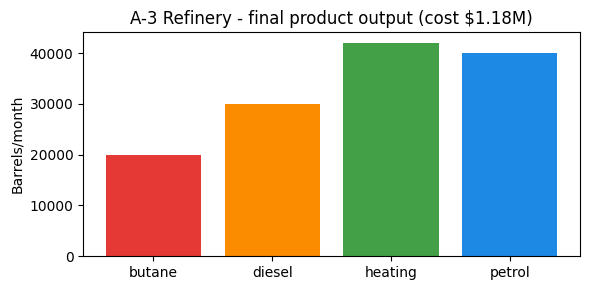

In [ ]:
products = sorted(sol_final.keys())
values   = [sol_final[p] for p in products]

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(products, values, color=["#E53935", "#FB8C00", "#43A047", "#1E88E5"])
ax.set_ylabel("Barrels/month")
ax.set_title(f"A-3 Refinery - final product output (cost ${obj_val/1e6:.2f}M)")
plt.tight_layout(); plt.show()

## A-4 Cane sugar production (MIP)

*Applications Book Chapter A, Example 4*

> **Mosel model:** [`a4sugar_p.mos`](models/mining_process/a4sugar_p.mos)

Eleven wagon loads of sugar cane must be processed on 3 production lines over at most 4 time slots. Each wagon has a loss rate (kg/hour); the later a wagon is processed, the more sugar is lost through fermentation. Binary variable $\text{process}_{w,s} = 1$ if wagon $w$ is assigned to slot $s$.

$$
\begin{align*}
\text{minimize}   \quad & \sum_{w,s} s \cdot \text{DUR} \cdot \text{LOSS}_w \cdot \text{process}_{w,s} \\
\text{subject to} \quad & \sum_s \text{process}_{w,s} = 1 \quad \forall\, w \quad \text{(each wagon in exactly one slot)} \\
                          & \sum_w \text{process}_{w,s} \leq 3 \quad \forall\, s \quad \text{(3 lines per slot)} \\
                          & \text{life constraints per wagon} \\
                          & \text{process}_{w,s} \in \{0, 1\}
\end{align*}
$$

Define the wagon fermentation loss rates and processing deadlines:

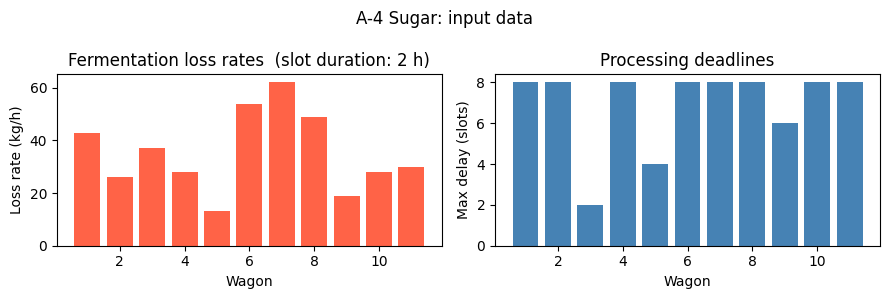

In [ ]:
NW, NL, NS = 11, 3, 4
LOSS = [43, 26, 37, 28, 13, 54, 62, 49, 19, 28, 30]
LIFE = [ 8,  8,  2,  8,  4,  8,  8,  8,  6,  8,  8]
DUR  = 2

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
wagons = list(range(1, NW+1))
axes[0].bar(wagons, LOSS, color="tomato")
axes[0].set_xlabel("Wagon"); axes[0].set_ylabel("Loss rate (kg/h)")
axes[0].set_title(f"Fermentation loss rates  (slot duration: {DUR} h)")
axes[1].bar(wagons, LIFE, color="steelblue")
axes[1].set_xlabel("Wagon"); axes[1].set_ylabel("Max delay (slots)")
axes[1].set_title("Processing deadlines")
plt.suptitle("A-4 Sugar: input data"); plt.tight_layout(); plt.show()

Compile and solve the scheduling MIP with `execute_model()`:

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/a4sugar_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"NW": NW, "NL": NL, "LOSS": LOSS, "LIFE": LIFE, "DUR": DUR},
)

obj_val     = output["obj_val"]
sol_process = output["sol_process"]  # dict with (wagon, slot) keys

schedule = {s: [w for w in range(1, NW+1) if sol_process.get((w, s), 0) > 0.5]
            for s in range(1, NS+1)}

print(f"Total sugar loss: {obj_val:.0f} kg")
print()
for s, wagons in schedule.items():
    print(f"Slot {s}: wagons {wagons}")

Total sugar loss: 1620 kg

Slot 1: wagons [3, 6, 7]
Slot 2: wagons [1, 5, 8]
Slot 3: wagons [4, 9, 11]
Slot 4: wagons [2, 10]


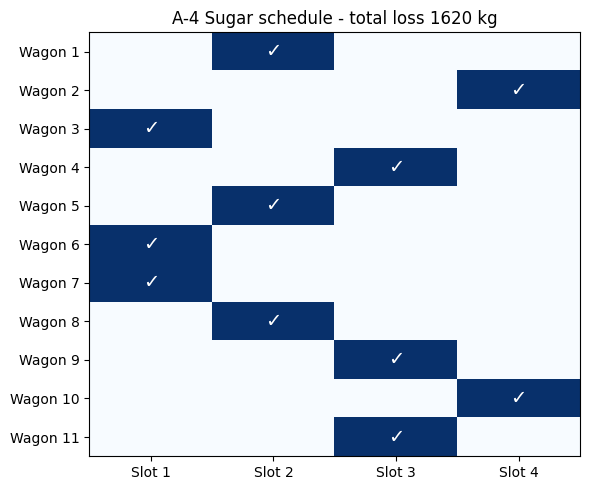

In [ ]:
NW, NS = 11, 4
grid = np.zeros((NW, NS))
for (w, s), v in sol_process.items():
    if v > 0.5:
        grid[w-1, s-1] = 1

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(grid, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(NS)); ax.set_xticklabels([f"Slot {s}" for s in range(1, NS+1)])
ax.set_yticks(range(NW)); ax.set_yticklabels([f"Wagon {w}" for w in range(1, NW+1)])
ax.set_title(f"A-4 Sugar schedule - total loss {obj_val:.0f} kg")
# Annotate assigned cells
for (w, s), v in sol_process.items():
    if v > 0.5:
        ax.text(s-1, w-1, "✓", ha="center", va="center", color="white", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## A-5 Opencast mining (MIP)

*Applications Book Chapter A, Example 5*

> **Mosel model:** [`a5mine_p.mos`](models/mining_process/a5mine_p.mos)

An opencast uranium mine has 18 blocks in 3 levels: 8 blocks in level 1, 6 in level 2, and 4 in level 3. To extract a block in level 2 or 3, the 3 blocks directly above it in the previous level must first be extracted. Each block has an extraction cost and a uranium value.

$\text{LEVEL23} = \text{NLO}..\text{NHI} = 9..18$ is the range of blocks subject to precedence constraints. $\text{ARC}_{b,i}$ gives the $i$-th predecessor block that must be extracted before block $b$. Binary variable $\text{extract}_b = 1$ if block $b$ is excavated.

$$
\begin{align*}
\text{maximize}   \quad & \sum_{b} (\text{VALUE}_b - \text{COST}_b) \cdot \text{extract}_b \\
\text{subject to} \quad & \text{extract}_b \leq \text{extract}_{\text{ARC}_{b,i}} \quad \forall\, b \in \text{LEVEL23},\ i \in \{1,2,3\} \\
                          & \text{extract}_b \in \{0,1\}
\end{align*}
$$

Define block extraction costs, uranium values, and the predecessor arc structure:

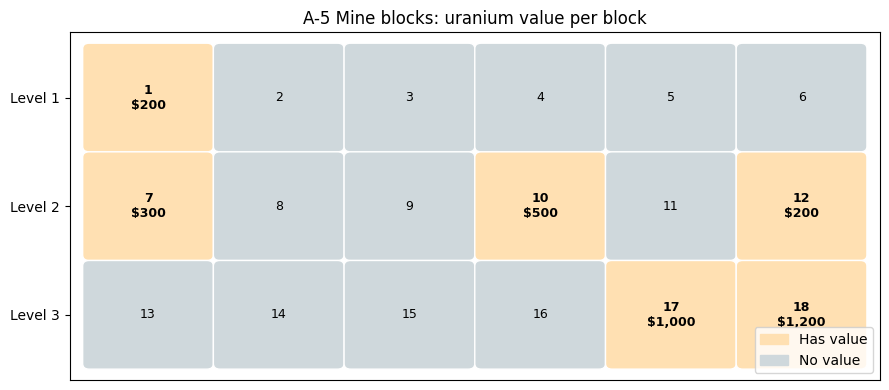

In [ ]:
NB, NLO, NHI = 18, 9, 18
COST  = [100,100,100,100,100,100,100,100,
         1000,200,200,200,200,1000,
         1000,1000,300,1000]
VALUE = {1: 200, 7: 300, 10: 500, 12: 200, 17: 1000, 18: 1200}
ARC   = {(9,1):1,(9,2):2,(9,3):3, (10,1):2,(10,2):3,(10,3):4,
         (11,1):3,(11,2):4,(11,3):5, (12,1):4,(12,2):5,(12,3):6,
         (13,1):5,(13,2):6,(13,3):7, (14,1):6,(14,2):7,(14,3):8,
         (15,1):9,(15,2):10,(15,3):11, (16,1):10,(16,2):11,(16,3):12,
         (17,1):11,(17,2):12,(17,3):13, (18,1):12,(18,2):13,(18,3):14}
WEIGHT = 10000

# Visualize mine blocks: uranium value per block
levels = [(1, 6), (7, 12), (13, 18)]
fig, ax = plt.subplots(figsize=(9, 4))
for row, (lo, hi) in enumerate(levels):
    for col, b in enumerate(range(lo, hi+1)):
        v = VALUE.get(b, 0)
        color = "#FFE0B2" if v > 0 else "#CFD8DC"
        rect = mpatches.FancyBboxPatch(
            (col - 0.45, -(row + 0.45)), 0.90, 0.90,
            boxstyle="round,pad=0.05", linewidth=1, edgecolor="white", facecolor=color
        )
        ax.add_patch(rect)
        label = f"{b}\n${v:,}" if v > 0 else str(b)
        ax.text(col, -row, label, ha="center", va="center", fontsize=9,
                fontweight="bold" if v > 0 else "normal")
ax.set_xlim(-0.6, 5.6); ax.set_ylim(-2.6, 0.6)
ax.set_yticks([0, -1, -2]); ax.set_yticklabels(["Level 1", "Level 2", "Level 3"])
ax.set_xticks([])
ax.set_title("A-5 Mine blocks: uranium value per block")
ax.legend(handles=[mpatches.Patch(color="#FFE0B2", label="Has value"),
                   mpatches.Patch(color="#CFD8DC", label="No value")], loc="lower right")
plt.tight_layout(); plt.show()

Compile and run `a5mine_p.mos` with predecessor data passed from Python. The `ARC` dict maps each level-2/3 block to its three required predecessor blocks using `(block, position)` tuple keys.

In [ ]:
mp.compile_model(f"{MODELS}/a5mine_p.mos", f"{MODELS}/a5mine_p.bim")
model = mp.load_model(f"{MODELS}/a5mine_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

out1 = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"COST": COST, "VALUE": VALUE, "ARC": ARC, "WEIGHT": WEIGHT},
)

if model.prob_status.is_solution_available:
    obj_val     = out1["obj_val"]
    sol_extract = out1["sol_extract"]
    extracted   = sorted([b for b, v in sol_extract.items() if v > 0.5])
    print(f"Total profit: ${obj_val:,.0f}")
    print(f"Blocks extracted: {extracted}")
else:
    print(f"No solution found ({model.prob_status})")

Total profit: $4,000,000
Blocks extracted: [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 17]


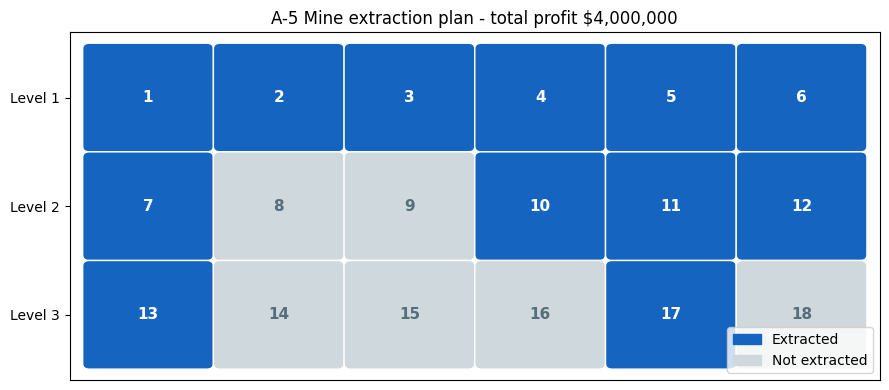

In [ ]:
# Visualize which blocks are extracted
n_per_level = 6
levels = [(1, 6), (7, 12), (13, 18)]   # (first_block, last_block) per level

fig, ax = plt.subplots(figsize=(9, 4))
for row, (lo, hi) in enumerate(levels):
    for col, b in enumerate(range(lo, hi+1)):
        extracted = sol_extract.get(b, 0) > 0.5
        color = "#1565C0" if extracted else "#CFD8DC"
        rect = mpatches.FancyBboxPatch(
            (col - 0.45, -(row + 0.45)), 0.90, 0.90,
            boxstyle="round,pad=0.05", linewidth=1,
            edgecolor="white", facecolor=color
        )
        ax.add_patch(rect)
        ax.text(col, -row, str(b), ha="center", va="center",
                color="white" if extracted else "#546E7A", fontsize=11, fontweight="bold")

ax.set_xlim(-0.6, n_per_level - 0.4)
ax.set_ylim(-2.6, 0.6)
ax.set_yticks([-0, -1, -2])
ax.set_yticklabels(["Level 1", "Level 2", "Level 3"])
ax.set_xticks([])
ax.set_title(f"A-5 Mine extraction plan - total profit ${obj_val:,.0f}")
blue_patch  = mpatches.Patch(color="#1565C0", label="Extracted")
grey_patch  = mpatches.Patch(color="#CFD8DC", label="Not extracted")
ax.legend(handles=[blue_patch, grey_patch], loc="lower right")
plt.tight_layout(); plt.show()

## A-6 Electricity production (MIP)

*Applications Book Chapter A, Example 6*

> **Mosel model:** [`a6electr_p.mos`](models/mining_process/a6electr_p.mos)

Four types of power generators must cover daily electricity demand across 7 time periods, plus a 20% security reserve. Each generator type has a minimum output (below which it cannot run) and a maximum capacity. Generators can only be started/stopped at period boundaries. Integer variable $\text{work}_{p,t}$ counts generators of type $p$ running in period $t$; continuous $\text{padd}_{p,t} \geq 0$ is extra output above the minimum.

$$
\begin{align*}
\text{minimize}   \quad & \sum_{p,t} \left( \text{CSTART}_p \cdot \text{start}_{p,t} + \text{LEN}_t(\text{CMIN}_p \cdot \text{work}_{p,t} + \text{CADD}_p \cdot \text{padd}_{p,t}) \right) \\
\text{subject to} \quad & \text{start}_{p,t} \geq \text{work}_{p,t} - \text{work}_{p,t-1} \quad \text{(start-up count)} \\
                          & \sum_p (\text{PMIN}_p \cdot \text{work}_{p,t} + \text{padd}_{p,t}) \geq \text{DEM}_t \quad \text{(demand)} \\
                          & \sum_p \text{PMAX}_p \cdot \text{work}_{p,t} \geq 1.2\,\text{DEM}_t \quad \text{(20\% reserve)} \\
                          & \text{work}_{p,t} \in \mathbb{Z}_{\geq 0},\ \text{work}_{p,t} \leq \text{AVAIL}_p
\end{align*}
$$

The graphical output originally produced by `a6electrg.mos` is reproduced here as a Python visualization.

Define the four generator types and the hourly demand profile across seven time periods:

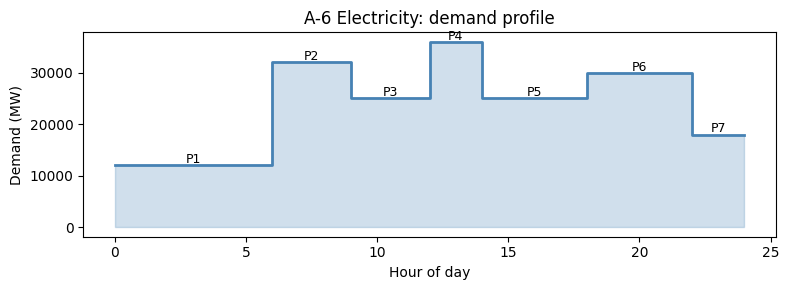

In [ ]:
NT, NP = 7, 4
LEN    = [6, 3, 3, 2, 4, 4, 2]
DEM    = [12000, 32000, 25000, 36000, 25000, 30000, 18000]
PMIN   = [750, 1000, 1200, 1800]
PMAX   = [1750, 1500, 2000, 3500]
CSTART = [5000, 1600, 2400, 1200]
CMIN   = [2250, 1800, 3750, 4800]
CADD   = [2.7, 2.2, 1.8, 3.8]
AVAIL  = [10, 4, 8, 3]

cum_h = [0]
for l in LEN:
    cum_h.append(cum_h[-1] + l)
dem_x, dem_y = [], []
for t in range(NT):
    dem_x += [cum_h[t], cum_h[t+1]]
    dem_y += [DEM[t], DEM[t]]

fig, ax = plt.subplots(figsize=(8, 3))
ax.fill_between(dem_x, dem_y, alpha=0.25, color="steelblue")
ax.plot(dem_x, dem_y, color="steelblue", linewidth=2)
for t in range(NT):
    ax.text((cum_h[t] + cum_h[t+1]) / 2, DEM[t] + 400, f"P{t+1}", ha="center", fontsize=9)
ax.set_xlabel("Hour of day"); ax.set_ylabel("Demand (MW)")
ax.set_title("A-6 Electricity: demand profile")
plt.tight_layout(); plt.show()

Compile and solve the electricity dispatch MIP:

In [ ]:
mp.compile_model(f"{MODELS}/a6electr_p.mos", f"{MODELS}/a6electr_p.bim")
model = mp.load_model(f"{MODELS}/a6electr_p.bim")
output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"NT": NT, "NP": NP, "LEN": LEN, "DEM": DEM, "PMIN": PMIN, "PMAX": PMAX,
                "CSTART": CSTART, "CMIN": CMIN, "CADD": CADD, "AVAIL": AVAIL},
)

obj_val  = output["obj_val"]
sol_work = output["sol_work"]   # (type, period) → int
sol_padd = output["sol_padd"]   # (type, period) → real

print(f"Daily cost: ${obj_val:,.0f}")
print()
print(f"{'Period':<8}", end="")
for t in range(1, NT+1):
    print(f"{t:>8}", end="")
print()
print(f"{'Demand':<8}", end="")
for t in range(1, NT+1):
    print(f"{DEM[t-1]:>8.0f}", end="")
print()
for p in range(1, NP+1):
    print(f"Type {p:<3}", end="")
    for t in range(1, NT+1):
        pwr = PMIN[p-1]*sol_work[(p,t)] + sol_padd[(p,t)]
        print(f"{pwr:>8.0f}", end="")
    print()

Daily cost: $1,465,810

Period         1       2       3       4       5       6       7
Demand     12000   32000   25000   36000   25000   30000   18000
Type 1      2250    4600    3000    8600    2250    2600    2250
Type 2      5750    6000    4200    6000    4950    6000    5950
Type 3      4000   16000   16000   16000   16000   16000    8000
Type 4         0    5400    1800    5400    1800    5400    1800


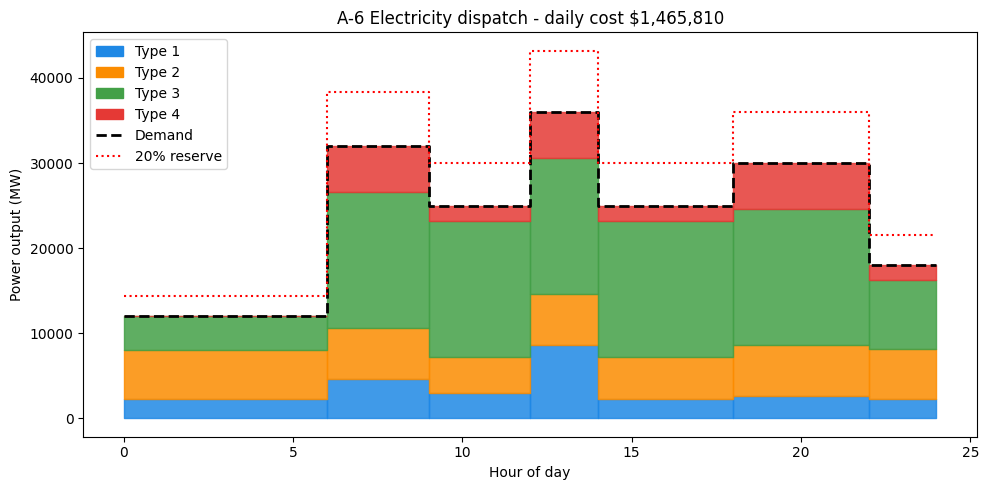

In [ ]:
NT, NP = 7, 4
type_labels  = [f"Type {p}" for p in range(1, NP+1)]
colors = ["#1E88E5", "#FB8C00", "#43A047", "#E53935"]

# Build cumulative hours for x-axis
cum_hours = [0]
for l in LEN:
    cum_hours.append(cum_hours[-1] + l)

# Output per type per period (MW * hours = MWh, but we plot MW levels)
pwr_matrix = np.array([[PMIN[p-1]*sol_work[(p,t)] + sol_padd[(p,t)]
                        for t in range(1, NT+1)] for p in range(1, NP+1)])

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(NT)
for p_idx in range(NP):
    for t in range(NT):
        x0, x1 = cum_hours[t], cum_hours[t+1]
        h = pwr_matrix[p_idx, t]
        ax.fill_between([x0, x1], [bottom[t], bottom[t]],
                        [bottom[t]+h, bottom[t]+h],
                        color=colors[p_idx], alpha=0.85)
        bottom[t] += h

# Demand line
demand_x = []
demand_y = []
for t in range(1, NT+1):
    demand_x += [cum_hours[t-1], cum_hours[t]]
    demand_y += [DEM[t-1], DEM[t-1]]
ax.step(demand_x, demand_y, where="post", color="black",
        linewidth=2, linestyle="--", label="Demand")

# 20% reserve line (minimum total capacity that must be available)
reserve_x = []
reserve_y = []
for t in range(1, NT+1):
    reserve_x += [cum_hours[t-1], cum_hours[t]]
    reserve_y += [1.2 * DEM[t-1], 1.2 * DEM[t-1]]
ax.step(reserve_x, reserve_y, where="post", color="red",
        linewidth=1.5, linestyle=":", label="20% reserve")

ax.set_xlabel("Hour of day")
ax.set_ylabel("Power output (MW)")
ax.set_title(f"A-6 Electricity dispatch - daily cost ${obj_val:,.0f}")
legend_patches = [mpatches.Patch(color=colors[i], label=type_labels[i]) for i in range(NP)]
legend_patches.append(plt.Line2D([0], [0], color="black", linewidth=2, linestyle="--", label="Demand"))
legend_patches.append(plt.Line2D([0], [0], color="red", linewidth=1.5, linestyle=":", label="20% reserve"))
ax.legend(handles=legend_patches, loc="upper left")
plt.tight_layout(); plt.show()

### Sensitivity analysis: varying demand

The loaded `model` can be run multiple times with different `input_data`; `run()` resets model state automatically before each execution. `prob_status.is_solution_optimal` confirms a valid solution before recording results.

In [ ]:
demand_factors = [0.7, 0.8, 0.9, 1.0]
rows = []
for factor in demand_factors:
    scaled_DEM = {t: int(DEM[t-1] * factor) for t in range(1, NT+1)}
    out = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
        input_data={"NT": NT, "NP": NP, "LEN": LEN, "DEM": scaled_DEM, "PMIN": PMIN, "PMAX": PMAX,
                    "CSTART": CSTART, "CMIN": CMIN, "CADD": CADD, "AVAIL": AVAIL},
    )
    if model.prob_status.is_solution_optimal:
        rows.append({"demand_factor": factor, "daily_cost": out["obj_val"]})

df = pd.DataFrame(rows).set_index("demand_factor")
print("A-6 Daily cost vs. demand scaling:")
print(df.to_string(float_format="${:,.0f}".format))

A-6 Daily cost vs. demand scaling:
               daily_cost
demand_factor            
0.7              $979,285
0.8            $1,139,620
0.9            $1,298,870
1.0            $1,465,810
